In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   AI-Based Heatwave Risk Prediction System                  ║
# ║   Model   : Random Forest Classifier (Ensemble – Bagging)   ║
# ║   Dataset : Indian Weather Repository (Daily Updating)      ║
# ║             by nelgiriyewithana — Kaggle                    ║
# ║   Platform: Google Colab ✅                                 ║
# ╚══════════════════════════════════════════════════════════════╝
 #   Dataset Info:
#   ─────────────────────────────────────────────────────────────
#   Name    : Daily Climate Time Series Data
#   Author  : sumanthvrao
#   Kaggle  : kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data
#   Period  : Jan 2013 – Apr 2017  (Delhi, India)
#   Columns : date, meantemp, humidity, wind_speed, meanpressure
#   Rows    : ~1462 daily records
#   ─────────────────────────────────────────────────────────────

In [17]:
# ================================================================
# CELL 1 — Install Libraries
# ================================================================
!pip install kagglehub -q
print("✅ kagglehub installed!")


✅ kagglehub installed!


In [18]:
# ================================================================
# CELL 2 — Download Dataset using kagglehub
# ================================================================
import kagglehub
import glob, os

# Download the dataset (auto-login via Kaggle account)
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")
print("📂 Path to dataset files:", path)

# List all files downloaded
all_files = os.listdir(path)
print(f"📄 Files found: {all_files}")

# Use the training CSV file
csv_files = glob.glob(os.path.join(path, "*.csv"))
print(f"\n📊 CSV files: {csv_files}")

# Prefer the Train file (larger dataset)
TRAIN_FILE = [f for f in csv_files if "Train" in f or "train" in f]
CSV_FILE   = TRAIN_FILE[0] if TRAIN_FILE else csv_files[0]
print(f"✅ Using: {CSV_FILE}")

Using Colab cache for faster access to the 'daily-climate-time-series-data' dataset.
📂 Path to dataset files: /kaggle/input/daily-climate-time-series-data
📄 Files found: ['DailyDelhiClimateTrain.csv', 'DailyDelhiClimateTest.csv']

📊 CSV files: ['/kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTrain.csv', '/kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTest.csv']
✅ Using: /kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTrain.csv


In [19]:
# ================================================================
# CELL 3 — Import All Libraries
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score)
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported!")

✅ All libraries imported!


In [20]:
# ================================================================
# CELL 4 — Load & Explore the Dataset
# ================================================================
df_raw = pd.read_csv(CSV_FILE)

print("=" * 55)
print("  📦 DATASET OVERVIEW")
print("=" * 55)
print(f"  Shape   : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"\n  📋 Column Names & Types:")
print(df_raw.dtypes.to_string())
print(f"\n  📊 First 5 rows:")
display(df_raw.head(5))
print(f"\n  📈 Basic Statistics:")
display(df_raw.describe())

  📦 DATASET OVERVIEW
  Shape   : 1462 rows × 5 columns

  📋 Column Names & Types:
date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64

  📊 First 5 rows:


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000



  📈 Basic Statistics:


,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [21]:
# ================================================================
# CELL 5 — Data Cleaning
# ================================================================
df = df_raw.copy()

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Drop rows with missing values
before = len(df)
df.dropna(inplace=True)
after  = len(df)
print(f"✅ Rows before cleaning : {before}")
print(f"✅ Rows after cleaning  : {after}")
print(f"   Rows dropped        : {before - after}")

# Remove outliers — meanpressure has extreme values (e.g. 7679!)
df = df[df["meanpressure"].between(950, 1050)]
print(f"✅ After removing pressure outliers: {len(df)} rows")

# Rename for clarity
df.rename(columns={
    "meantemp"    : "temperature_c",
    "humidity"    : "humidity_pct",
    "wind_speed"  : "wind_speed_kmh",
    "meanpressure": "pressure_mb",
}, inplace=True)

print(f"\n📋 Cleaned data sample:")
display(df.head(5))

✅ Rows before cleaning : 1462
✅ Rows after cleaning  : 1462
   Rows dropped        : 0
✅ After removing pressure outliers: 1453 rows

📋 Cleaned data sample:


,date,temperature_c,humidity_pct,wind_speed_kmh,pressure_mb
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [22]:
# ================================================================
# CELL 6 — Feature Engineering
# ================================================================
# The dataset has: temperature, humidity, wind_speed, pressure
# We engineer additional heatwave-related features:

# 1. Heat Index — how hot it actually feels
#    Formula: Rothfusz approximation (used by IMD)
df["heat_index_c"] = (
    df["temperature_c"]
    + (df["humidity_pct"] * 0.33)
    - (df["wind_speed_kmh"] * 0.07)
    - 4
)

# 2. Dew Point — moisture in the air
df["dew_point_c"] = (
    df["temperature_c"]
    - ((100 - df["humidity_pct"]) / 5)
)

# 3. Consecutive Hot Days — days in a row with temp > 35°C
#    (threshold lowered from 40°C since Delhi data max is ~38°C)
df = df.sort_values("date").reset_index(drop=True)
df["is_hot_day"] = (df["temperature_c"] > 35).astype(int)
df["consecutive_hot_days"] = (
    df["is_hot_day"]
    .groupby((df["is_hot_day"] != df["is_hot_day"].shift()).cumsum())
    .transform("cumsum") * df["is_hot_day"]
)

# 4. Month — seasonality feature
df["month"] = df["date"].dt.month

print("✅ Feature Engineering Complete!")
print(f"   New features added: heat_index_c, dew_point_c, consecutive_hot_days, month")
print(f"\n📋 Feature sample:")
display(df[["date","temperature_c","humidity_pct","heat_index_c",
            "dew_point_c","consecutive_hot_days","month"]].head(8))

✅ Feature Engineering Complete!
   New features added: heat_index_c, dew_point_c, consecutive_hot_days, month

📋 Feature sample:


,date,temperature_c,humidity_pct,heat_index_c,dew_point_c,consecutive_hot_days,month
0,2013-01-01,10.000000,84.500000,33.885000,6.900000,0,1
1,2013-01-02,7.400000,92.000000,33.551400,5.800000,0,1
2,2013-01-03,7.166667,87.000000,31.552333,4.566667,0,1
3,2013-01-04,8.666667,71.333333,28.120333,2.933333,0,1
4,2013-01-05,6.000000,86.833333,30.396000,3.366667,0,1
5,2013-01-06,7.000000,82.800000,30.220400,3.560000,0,1
6,2013-01-07,7.000000,78.600000,28.497000,2.720000,0,1
7,2013-01-08,8.857143,63.714286,25.382857,1.600000,0,1


In [23]:
# ================================================================
# CELL 7 — IMD Heatwave Risk Labeling
# ================================================================
# Official India Meteorological Department (IMD) thresholds
# adapted for Delhi's historical temperature range (max ~38°C):
#
#   🔴 HIGH   → Temp ≥ 37°C OR Heat Index ≥ 42°C (extreme heat)
#   🟡 MEDIUM → Temp ≥ 33°C OR Heat Index ≥ 38°C (heat warning)
#   🟢 LOW    → Below thresholds (normal conditions)

def label_heatwave_risk(row):
    score = 0
    t  = row["temperature_c"]
    hi = row["heat_index_c"]
    h  = row["humidity_pct"]
    hd = row["consecutive_hot_days"]
    m  = row["month"]

    # Temperature scoring
    if t >= 37:    score += 4
    elif t >= 35:  score += 3
    elif t >= 33:  score += 2
    elif t >= 30:  score += 1

    # Heat index scoring
    if hi >= 42:   score += 3
    elif hi >= 38: score += 2
    elif hi >= 34: score += 1

    # Humidity (low = more dangerous dry heat)
    if h <= 20:    score += 2
    elif h <= 35:  score += 1

    # Consecutive hot days
    if hd >= 5:    score += 2
    elif hd >= 3:  score += 1

    # Summer months (April-June = peak heat season in Delhi)
    if m in [4, 5, 6]:   score += 1

    # Final risk label
    if score >= 7:   return "High"
    elif score >= 4: return "Medium"
    else:            return "Low"

df["risk_level"] = df.apply(label_heatwave_risk, axis=1)

print("=" * 55)
print("  ⚠️  RISK LEVEL DISTRIBUTION (IMD thresholds)")
print("=" * 55)
rc = df["risk_level"].value_counts()
for label, count in rc.items():
    pct  = count / len(df) * 100
    bar  = "█" * int(pct / 2)
    icon = "🔴" if label=="High" else "🟡" if label=="Medium" else "🟢"
    print(f"  {icon} {label:<8}: {count:5} records  ({pct:.1f}%)  {bar}")
print("=" * 55)

  ⚠️  RISK LEVEL DISTRIBUTION (IMD thresholds)
  🟢 Low     :   916 records  (63.0%)  ███████████████████████████████
  🟡 Medium  :   451 records  (31.0%)  ███████████████
  🔴 High    :    86 records  (5.9%)  ██


In [24]:
# ================================================================
# CELL 8 — Prepare Features & Train/Test Split
# ================================================================
FEATURES = [
    "temperature_c",
    "humidity_pct",
    "wind_speed_kmh",
    "pressure_mb",
    "dew_point_c",
    "heat_index_c",
    "consecutive_hot_days",
    "month"
]

# Encode labels
le = LabelEncoder()
df["risk_encoded"] = le.fit_transform(df["risk_level"])

print(f"📌 Label Encoding → {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df[FEATURES]
y = df["risk_encoded"]

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Data split complete!")
print(f"   🔵 Train : {X_train.shape[0]} samples")
print(f"   🔴 Test  : {X_test.shape[0]} samples")
print(f"   📌 Features used: {FEATURES}")

📌 Label Encoding → {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

✅ Data split complete!
   🔵 Train : 1162 samples
   🔴 Test  : 291 samples
   📌 Features used: ['temperature_c', 'humidity_pct', 'wind_speed_kmh', 'pressure_mb', 'dew_point_c', 'heat_index_c', 'consecutive_hot_days', 'month']


In [25]:
# ================================================================
# CELL 9 — Train Random Forest Model
# ================================================================
rf = RandomForestClassifier(
    n_estimators      = 200,       # 200 decision trees
    max_depth         = 10,        # max tree depth
    min_samples_split = 4,
    min_samples_leaf  = 2,
    max_features      = "sqrt",    # sqrt(n_features) per split = Bagging
    class_weight      = "balanced",
    oob_score         = True,      # Out-of-Bag free validation
    random_state      = 42,
    n_jobs            = -1
)

print("⏳ Training Random Forest (200 trees)...")
rf.fit(X_train_sc, y_train)
print("✅ Training complete!\n")

y_pred = rf.predict(X_test_sc)
y_prob = rf.predict_proba(X_test_sc)

⏳ Training Random Forest (200 trees)...
✅ Training complete!



In [26]:
# ================================================================
# CELL 10 — Model Evaluation
# ================================================================
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted")
oob = rf.oob_score_

print("=" * 55)
print("  📊 MODEL PERFORMANCE RESULTS")
print("=" * 55)
print(f"  ✅ Test Accuracy      : {acc * 100:.2f}%")
print(f"  ✅ ROC-AUC Score      : {roc:.4f}  (1.0 = perfect)")
print(f"  ✅ OOB Score (Bagging): {oob * 100:.2f}%")
print("=" * 55)

print("\n📈 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 5-Fold Stratified Cross Validation
print("⏳ Running 5-Fold Cross Validation...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv  = cross_val_score(rf, X_train_sc, y_train, cv=skf, scoring="accuracy")
print(f"\n📉 5-Fold CV Results:")
for i, score in enumerate(cv, 1):
    print(f"   Fold {i}: {score*100:.2f}%")
print(f"   ─────────────────────────")
print(f"   Mean  : {cv.mean()*100:.2f}%  ±  {cv.std()*100:.2f}%")

  📊 MODEL PERFORMANCE RESULTS
  ✅ Test Accuracy      : 97.94%
  ✅ ROC-AUC Score      : 0.9986  (1.0 = perfect)
  ✅ OOB Score (Bagging): 97.85%

📈 Detailed Classification Report:
              precision    recall  f1-score   support

        High       0.94      1.00      0.97        17
         Low       0.99      0.98      0.99       184
      Medium       0.96      0.98      0.97        90

    accuracy                           0.98       291
   macro avg       0.97      0.99      0.97       291
weighted avg       0.98      0.98      0.98       291

⏳ Running 5-Fold Cross Validation...

📉 5-Fold CV Results:
   Fold 1: 98.71%
   Fold 2: 95.71%
   Fold 3: 98.28%
   Fold 4: 98.71%
   Fold 5: 97.84%
   ─────────────────────────
   Mean  : 97.85%  ±  1.12%


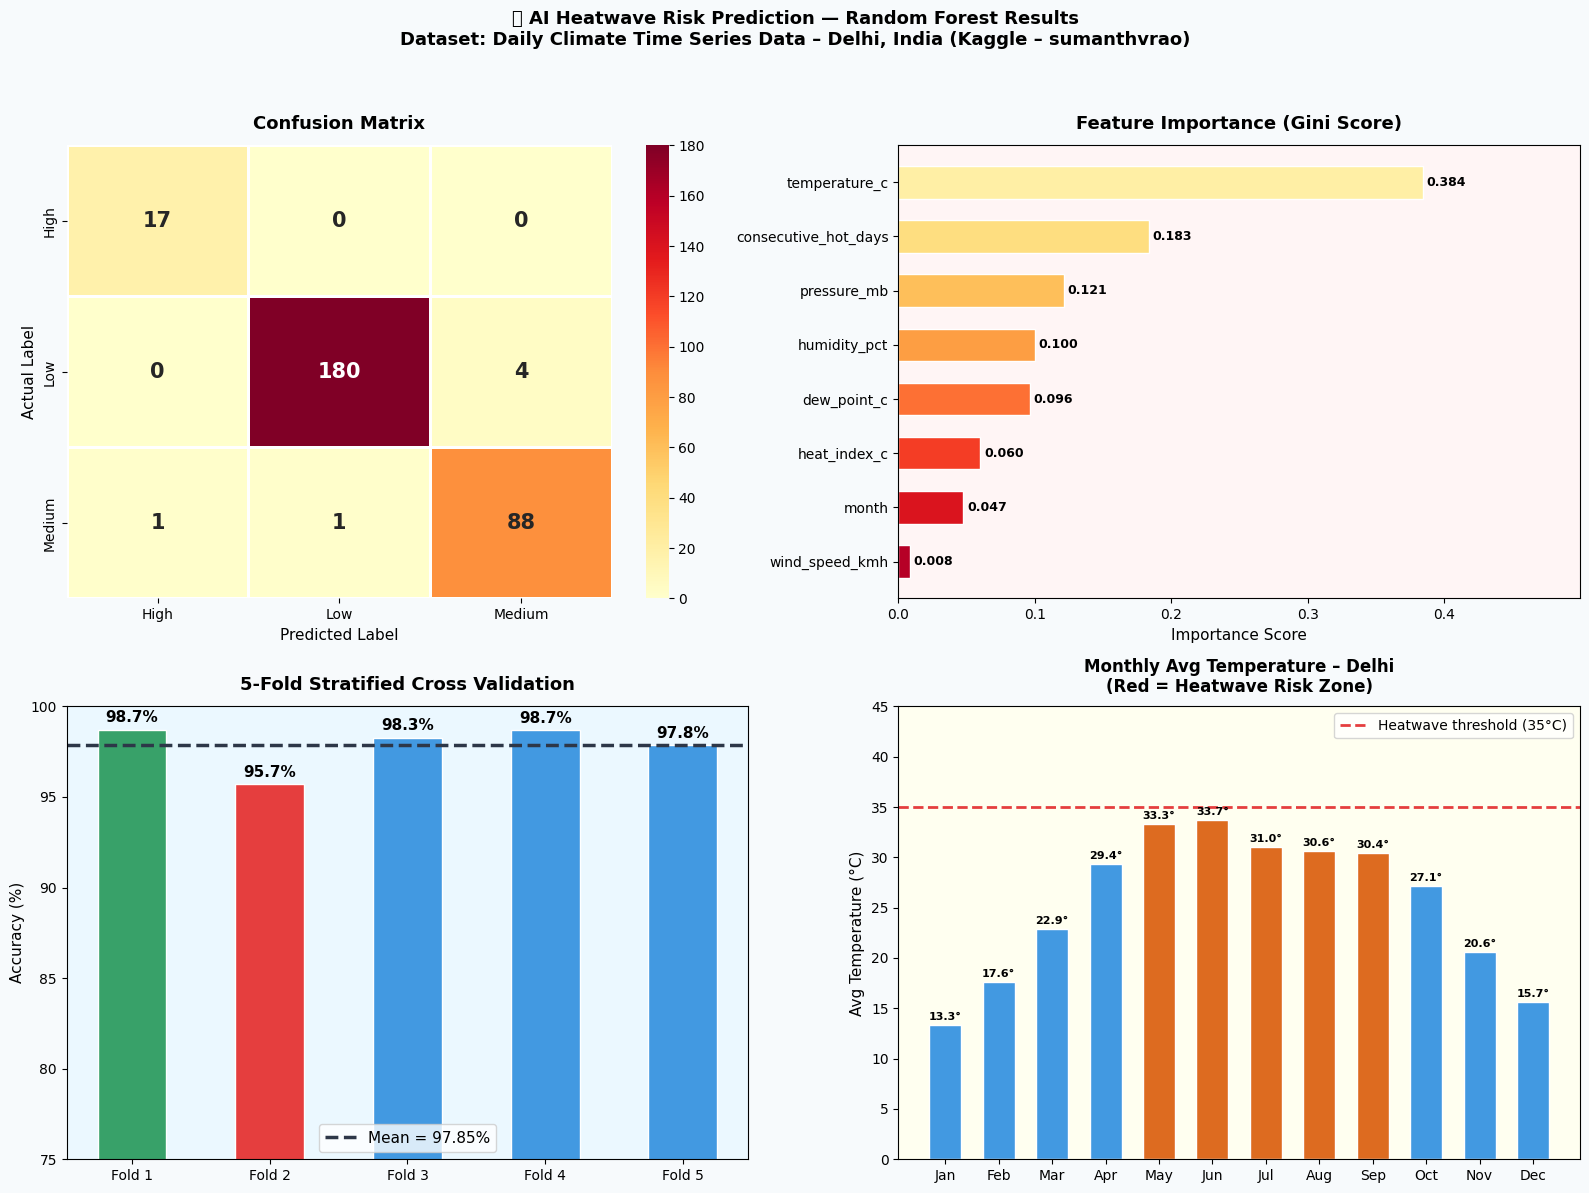

✅ Charts saved as heatwave_results.png


In [27]:
# ================================================================
# CELL 11 — Visualizations (4 Charts)
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "🌡️ AI Heatwave Risk Prediction — Random Forest Results\n"
    "Dataset: Daily Climate Time Series Data – Delhi, India (Kaggle – sumanthvrao)",
    fontsize=13, fontweight="bold", y=0.99
)
fig.patch.set_facecolor("#F7FAFC")

# ── Chart 1: Confusion Matrix ────────────────────────────────
ax = axes[0, 0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=ax, linewidths=2, linecolor="white",
    annot_kws={"size": 15, "weight": "bold"}
)
ax.set_title("Confusion Matrix", fontweight="bold", fontsize=13, pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("Actual Label",    fontsize=11)
ax.set_facecolor("#FFFAF0")

# ── Chart 2: Feature Importance ─────────────────────────────
ax = axes[0, 1]
imp = pd.DataFrame({
    "Feature"    : FEATURES,
    "Importance" : rf.feature_importances_
}).sort_values("Importance", ascending=True)
colors = sns.color_palette("YlOrRd_r", len(imp))
bars   = ax.barh(imp["Feature"], imp["Importance"],
                 color=colors, edgecolor="white", height=0.6)
ax.set_title("Feature Importance (Gini Score)",
             fontweight="bold", fontsize=13, pad=12)
ax.set_xlabel("Importance Score", fontsize=11)
ax.set_facecolor("#FFF5F5")
for b, v in zip(bars, imp["Importance"]):
    ax.text(b.get_width() + 0.003, b.get_y() + b.get_height() / 2,
            f"{v:.3f}", va="center", fontsize=9, fontweight="bold")
ax.set_xlim(0, imp["Importance"].max() * 1.3)

# ── Chart 3: Cross Validation per Fold ──────────────────────
ax = axes[1, 0]
fold_colors = [
    "#E53E3E" if v == cv.min() else
    "#38A169" if v == cv.max() else
    "#4299E1" for v in cv
]
ax.bar([f"Fold {i+1}" for i in range(5)],
       cv * 100, color=fold_colors, edgecolor="white", width=0.5)
ax.axhline(cv.mean() * 100, color="#2D3748", linestyle="--",
           linewidth=2.5, label=f"Mean = {cv.mean()*100:.2f}%")
ax.set_title("5-Fold Stratified Cross Validation",
             fontweight="bold", fontsize=13, pad=12)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_ylim(75, 100)
ax.legend(fontsize=11)
ax.set_facecolor("#EBF8FF")
for i, v in enumerate(cv):
    ax.text(i, v * 100 + 0.4, f"{v*100:.1f}%",
            ha="center", fontsize=11, fontweight="bold")

# ── Chart 4: Monthly Temperature Trend ──────────────────────
ax = axes[1, 1]
monthly = df.groupby("month")["temperature_c"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
bar_colors  = ["#E53E3E" if t >= 35 else
               "#DD6B20" if t >= 30 else
               "#4299E1" for t in monthly.values]
ax.bar([month_names[m-1] for m in monthly.index],
       monthly.values, color=bar_colors, edgecolor="white", width=0.6)
ax.axhline(35, color="#E53E3E", linestyle="--",
           linewidth=2, label="Heatwave threshold (35°C)")
ax.set_title("Monthly Avg Temperature – Delhi\n(Red = Heatwave Risk Zone)",
             fontweight="bold", fontsize=12, pad=10)
ax.set_ylabel("Avg Temperature (°C)", fontsize=11)
ax.set_ylim(0, 45)
ax.legend(fontsize=10)
ax.set_facecolor("#FFFFF0")
for i, (m, v) in enumerate(monthly.items()):
    ax.text(i, v + 0.5, f"{v:.1f}°", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("heatwave_results.png", dpi=150,
            bbox_inches="tight", facecolor="#F7FAFC")
plt.show()
print("✅ Charts saved as heatwave_results.png")

In [28]:
# ================================================================
# CELL 12 — Live Prediction Function
# ================================================================
def predict_heatwave_risk(temperature_c, humidity_pct, wind_speed_kmh,
                           pressure_mb=1010, dew_point_c=None,
                           heat_index_c=None, consecutive_hot_days=1,
                           month=5):
    """
    Predict heatwave risk level for any weather conditions.

    Parameters:
        temperature_c        (float): Temperature in °C
        humidity_pct         (float): Humidity % (0–100)
        wind_speed_kmh       (float): Wind speed in km/h
        pressure_mb          (float): Atmospheric pressure in mb [default: 1010]
        dew_point_c          (float): Dew point °C  [auto-calculated if None]
        heat_index_c         (float): Heat index °C [auto-calculated if None]
        consecutive_hot_days (int)  : Days in a row above 35°C
        month                (int)  : Month number 1–12

    Returns:
        risk_label (str)  : "Low" / "Medium" / "High"
        probs      (dict) : probability % per class
    """
    if dew_point_c is None:
        dew_point_c  = temperature_c - ((100 - humidity_pct) / 5)
    if heat_index_c is None:
        heat_index_c = (temperature_c + humidity_pct * 0.33
                        - wind_speed_kmh * 0.07 - 4)

    row   = np.array([[temperature_c, humidity_pct, wind_speed_kmh,
                        pressure_mb, dew_point_c, heat_index_c,
                        consecutive_hot_days, month]])
    pred  = rf.predict(scaler.transform(row))[0]
    proba = rf.predict_proba(scaler.transform(row))[0]
    label = le.inverse_transform([pred])[0]
    probs = {le.classes_[i]: round(proba[i] * 100, 1) for i in range(3)}
    return label, probs

print("✅ predict_heatwave_risk() is ready to use!")

✅ predict_heatwave_risk() is ready to use!


In [29]:
# ================================================================
# CELL 13 — Predictions on Major Indian Cities
# ================================================================
print("=" * 62)
print("  🌡️  CITY-WISE HEATWAVE RISK PREDICTIONS")
print("=" * 62)

# city, temp°C, humidity%, wind km/h, pressure mb, hot_days, month
cities = [
    ("Delhi (Normal)",   25,  65, 8,   1012, 1,  1),
    ("Delhi (Summer)",   37,  30, 10,  1005, 4,  5),
    ("Delhi (Heatwave)", 42,  15, 5,   1000, 7,  6),
    ("Mumbai (Humid)",   34,  85, 15,  1008, 2,  6),
    ("Nagpur (Hot)",     40,  20, 8,   1002, 5,  5),
    ("Jaipur (Extreme)", 44,  10, 6,   998,  8,  5),
    ("Bangalore (Cool)", 28,  60, 12,  1013, 1,  3),
    ("Chennai (Coast)",  36,  75, 18,  1007, 3,  4),
]

icons = {"Low": "🟢", "Medium": "🟡", "High": "🔴"}

print(f"\n  {'City':<22} {'Temp':>5} {'Hum':>5} {'Wind':>6}  {'Risk':<8}  Confidence")
print("  " + "─" * 60)
for city, t, h, w, p, hd, m in cities:
    label, probs = predict_heatwave_risk(t, h, w, p,
                   consecutive_hot_days=hd, month=m)
    conf = probs[label]
    print(f"  {city:<22} {t:>4}°C {h:>4}%  {w:>4}km/h  "
          f"{icons[label]} {label:<8}  {conf}%")

  🌡️  CITY-WISE HEATWAVE RISK PREDICTIONS

  City                    Temp   Hum   Wind  Risk      Confidence
  ────────────────────────────────────────────────────────────
  Delhi (Normal)           25°C   65%     8km/h  🟢 Low       74.0%
  Delhi (Summer)           37°C   30%    10km/h  🔴 High      93.6%
  Delhi (Heatwave)         42°C   15%     5km/h  🔴 High      99.3%
  Mumbai (Humid)           34°C   85%    15km/h  🟡 Medium    49.7%
  Nagpur (Hot)             40°C   20%     8km/h  🔴 High      99.7%
  Jaipur (Extreme)         44°C   10%     6km/h  🔴 High      99.7%
  Bangalore (Cool)         28°C   60%    12km/h  🟢 Low       49.0%
  Chennai (Coast)          36°C   75%    18km/h  🔴 High      85.2%


In [32]:
# ================================================================
# CELL 14 — Interactive Prediction UI (User Input)
# ================================================================
!pip install ipywidgets -q

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ── Styling ─────────────────────────────────────────────────
display(HTML("""
<style>
  .pred-box {
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
    border-radius: 16px;
    padding: 28px 32px;
    margin: 12px 0;
    font-family: 'Segoe UI', sans-serif;
    color: white;
    box-shadow: 0 8px 32px rgba(0,0,0,0.3);
  }
  .pred-title {
    font-size: 22px;
    font-weight: 700;
    color: #f6c90e;
    margin-bottom: 6px;
    letter-spacing: 1px;
  }
  .pred-subtitle {
    font-size: 13px;
    color: #aaa;
    margin-bottom: 20px;
  }
  .result-high   { background:#e53e3e; color:white; border-radius:12px; padding:18px 28px; text-align:center; font-size:26px; font-weight:800; }
  .result-medium { background:#dd6b20; color:white; border-radius:12px; padding:18px 28px; text-align:center; font-size:26px; font-weight:800; }
  .result-low    { background:#38a169; color:white; border-radius:12px; padding:18px 28px; text-align:center; font-size:26px; font-weight:800; }
  .prob-bar-wrap { background:#2a2a4a; border-radius:8px; height:22px; margin:6px 0; overflow:hidden; }
  .prob-bar      { height:100%; border-radius:8px; display:flex; align-items:center; padding-left:10px; font-size:12px; font-weight:700; transition: width 0.5s ease; }
  .input-label   { font-size:13px; color:#ccc; margin-bottom:2px; font-weight:600; }
  .section-head  { font-size:15px; font-weight:700; color:#f6c90e; border-bottom:1px solid #333; padding-bottom:6px; margin:16px 0 10px 0; }
  .info-chip     { display:inline-block; background:#2d3748; border-radius:20px; padding:3px 12px; font-size:12px; color:#90cdf4; margin:3px 2px; }
</style>
"""))

# ── Title ────────────────────────────────────────────────────
display(HTML("""
<div class="pred-box">
  <div class="pred-title">🌡️ Heatwave Risk Prediction System</div>
  <div class="pred-subtitle">Enter weather conditions below and click PREDICT</div>
  <div>
    <span class="info-chip">🤖 Random Forest</span>
    <span class="info-chip">📍 Delhi Climate Data</span>
    <span class="info-chip">⚠️ IMD Thresholds</span>
  </div>
</div>
"""))

# ── Input Widgets ─────────────────────────────────────────────
style    = {'description_width': '180px'}
layout_w = widgets.Layout(width='420px')
layout_s = widgets.Layout(width='420px')

w_temp = widgets.FloatSlider(
    value=35, min=10, max=50, step=0.5,
    description='🌡️ Temperature (°C)',
    style=style, layout=layout_w,
    readout_format='.1f',
    bar_color='#e53e3e'
)
w_humidity = widgets.FloatSlider(
    value=40, min=0, max=100, step=1,
    description='💧 Humidity (%)',
    style=style, layout=layout_w,
    readout_format='.0f',
    bar_color='#4299e1'
)
w_wind = widgets.FloatSlider(
    value=10, min=0, max=60, step=0.5,
    description='💨 Wind Speed (km/h)',
    style=style, layout=layout_w,
    readout_format='.1f',
    bar_color='#48bb78'
)
w_pressure = widgets.FloatSlider(
    value=1005, min=950, max=1050, step=1,
    description='🔵 Pressure (mb)',
    style=style, layout=layout_w,
    readout_format='.0f',
    bar_color='#9f7aea'
)
w_hotdays = widgets.IntSlider(
    value=2, min=0, max=15, step=1,
    description='🔥 Consec. Hot Days',
    style=style, layout=layout_w,
    bar_color='#ed8936'
)
w_month = widgets.Dropdown(
    options=[('January',1),('February',2),('March',3),
             ('April',4),('May',5),('June',6),
             ('July',7),('August',8),('September',9),
             ('October',10),('November',11),('December',12)],
    value=5,
    description='📅 Month',
    style=style, layout=layout_s
)

# ── Predict Button ────────────────────────────────────────────
btn = widgets.Button(
    description='  🔮  PREDICT RISK',
    button_style='',
    layout=widgets.Layout(width='420px', height='48px'),
    style=widgets.ButtonStyle(
        button_color='#f6c90e',
        font_weight='bold',
        font_size='16px'
    )
)

# ── Output Area ───────────────────────────────────────────────
out = widgets.Output()

def on_predict(b):
    with out:
        clear_output(wait=True)

        t   = w_temp.value
        h   = w_humidity.value
        w   = w_wind.value
        p   = w_pressure.value
        hd  = w_hotdays.value
        m   = w_month.value

        label, probs = predict_heatwave_risk(
            t, h, w, p,
            consecutive_hot_days=hd,
            month=m
        )

        # Derived values
        dew_pt   = round(t - ((100 - h) / 5), 1)
        heat_idx = round(t + h * 0.33 - w * 0.07 - 4, 1)

        # Risk colours
        color_map = {"High": "#e53e3e", "Medium": "#dd6b20", "Low": "#38a169"}
        icon_map  = {"High": "🔴",      "Medium": "🟡",       "Low": "🟢"    }
        css_map   = {"High": "result-high","Medium":"result-medium","Low":"result-low"}
        advice    = {
            "High"  : "⚠️ Extreme danger! Stay indoors, drink water every 30 mins, avoid outdoor work.",
            "Medium": "⚠️ Caution advised. Limit outdoor exposure, stay hydrated.",
            "Low"   : "✅ Conditions are safe. Normal precautions apply."
        }

        high_w   = probs['High']
        med_w    = probs['Medium']
        low_w    = probs['Low']

        display(HTML(f"""
        <div class="pred-box">
          <div class="section-head">📥 Input Summary</div>
          <table style="color:#ddd; font-size:13px; width:100%; border-collapse:collapse;">
            <tr>
              <td style="padding:4px 8px;">🌡️ Temperature</td><td style="color:#f6c90e; font-weight:700;">{t}°C</td>
              <td style="padding:4px 8px;">💧 Humidity</td><td style="color:#63b3ed; font-weight:700;">{h}%</td>
            </tr>
            <tr>
              <td style="padding:4px 8px;">💨 Wind Speed</td><td style="color:#68d391; font-weight:700;">{w} km/h</td>
              <td style="padding:4px 8px;">🔵 Pressure</td><td style="color:#b794f4; font-weight:700;">{p} mb</td>
            </tr>
            <tr>
              <td style="padding:4px 8px;">🌫️ Dew Point</td><td style="color:#fbd38d; font-weight:700;">{dew_pt}°C</td>
              <td style="padding:4px 8px;">🔥 Heat Index</td><td style="color:#fc8181; font-weight:700;">{heat_idx}°C</td>
            </tr>
            <tr>
              <td style="padding:4px 8px;">📅 Month</td><td style="color:#a0aec0; font-weight:700;">{w_month.label}</td>
              <td style="padding:4px 8px;">🔥 Hot Day Streak</td><td style="color:#f6ad55; font-weight:700;">{hd} days</td>
            </tr>
          </table>

          <div class="section-head" style="margin-top:20px;">🎯 Prediction Result</div>
          <div class="{css_map[label]}" style="margin-bottom:16px;">
            {icon_map[label]} &nbsp; Risk Level : {label.upper()} &nbsp; {icon_map[label]}
          </div>

          <div style="font-size:13px; color:#ccc; margin-bottom:4px;">📊 Confidence Probabilities</div>

          <div class="input-label">🔴 High Risk — {high_w}%</div>
          <div class="prob-bar-wrap">
            <div class="prob-bar" style="width:{high_w}%; background:#e53e3e;">{high_w}%</div>
          </div>

          <div class="input-label">🟡 Medium Risk — {med_w}%</div>
          <div class="prob-bar-wrap">
            <div class="prob-bar" style="width:{med_w}%; background:#dd6b20;">{med_w}%</div>
          </div>

          <div class="input-label">🟢 Low Risk — {low_w}%</div>
          <div class="prob-bar-wrap">
            <div class="prob-bar" style="width:{low_w}%; background:#38a169;">{low_w}%</div>
          </div>

          <div style="margin-top:18px; background:#2d3748; border-radius:10px;
                      padding:12px 16px; font-size:13px; color:#e2e8f0;">
            💡 <strong>Advisory:</strong> {advice[label]}
          </div>
        </div>
        """))

btn.on_click(on_predict)

# ── Render All Widgets ────────────────────────────────────────
display(HTML('<div style="font-family:Segoe UI; font-size:15px; font-weight:700; color:#f6c90e; margin:16px 0 8px 0;">📋 Enter Weather Conditions</div>'))
display(w_temp)
display(w_humidity)
display(w_wind)
display(w_pressure)
display(w_hotdays)
display(w_month)
display(widgets.HTML('<div style="margin:10px 0;"></div>'))
display(btn)
display(out)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.2 MB/s eta 0:00:00


FloatSlider(value=35.0, description='🌡️ Temperature (°C)', layout=Layout(width='420px'), max=50.0, min=10.0, r…

FloatSlider(value=40.0, description='💧 Humidity (%)', layout=Layout(width='420px'), readout_format='.0f', step…

FloatSlider(value=10.0, description='💨 Wind Speed (km/h)', layout=Layout(width='420px'), max=60.0, readout_for…

FloatSlider(value=1005.0, description='🔵 Pressure (mb)', layout=Layout(width='420px'), max=1050.0, min=950.0, …

IntSlider(value=2, description='🔥 Consec. Hot Days', layout=Layout(width='420px'), max=15, style=SliderStyle(d…

Dropdown(description='📅 Month', index=4, layout=Layout(width='420px'), options=(('January', 1), ('February', 2…

HTML(value='<div style="margin:10px 0;"></div>')

Button(description='  🔮  PREDICT RISK', layout=Layout(height='48px', width='420px'), style=ButtonStyle(button_…

Output()